In [1]:
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import tqdm as tqdm
from BaselineRemoval import BaselineRemoval # Ensure this library is in your path
import numpy as np

## Define Functions to Load and Manipulate Data

In [2]:
#FTNIR-csv input
def processing(fp):
    # 1. SETUP & DATA LOADING
    # Update path to look for .csv files
    file_paths = glob.glob(fp)

    # Lists to store data
    intensities_list = []
    wavenumber_col = None

    # Loop through each file to build the dataset
    for i, filename in enumerate(file_paths):
        # Read CSV. standard CSVs use comma delimiter. 
        # header=None assumes no text headers (row 0 is data). 
        # If your files have headers like "Wave, Int", change to header=0
        df = pd.read_csv(filename, header=None)
        
        # Capture Wavenumber from the very first file only (Column 0)
        if i == 0:
            wavenumber_col = df.iloc[:, 0]
        
        # Capture Intensity from every file (Column 1)
        intensities_list.append(df.iloc[:, 1])

    # Create the master DataFrame: Wavenumber + All Intensities
    # axis=1 stacks them side-by-side
    rslt_df = pd.concat([wavenumber_col] + intensities_list, axis=1)

    # Generate column names (A, B, C...) to match the logic your processing steps expect
    # 'A' will be Wavenumber, 'B' onwards will be intensities
    rslt_df.columns = [chr(i + ord('A')) for i in range(rslt_df.shape[1])]
    rslt_df.rename(columns={'A': 'Wavenumber'}, inplace=True)


    # 2. COSMIC RAY REMOVAL
    def modified_z_score(intensity):
        median_int = np.median(intensity)
        mad_int = np.median(np.abs(intensity - median_int))
        # Avoid division by zero if MAD is 0
        if mad_int == 0:
            return np.zeros_like(intensity)
        modified_z_scores = 0.6745 * (intensity - median_int) / mad_int
        return modified_z_scores

    def fixer(y, m):
        threshold = 5 # binarization threshold. 
        y = np.array(y)
        
        # --- FIX START ---
        # np.diff(y) returns an array shorter by 1. 
        # We append a 0 to make 'diff' the same length as 'y' so indices match.
        diff_y = np.diff(y)
        diff_y = np.append(diff_y, 0) 
        # --- FIX END ---
        
        spikes = abs(np.array(modified_z_score(diff_y))) > threshold
        y_out = y.copy() 
        
        for i in np.arange(len(spikes)):
            if spikes[i] != 0: 
                w = np.arange(i-m, i+1+m) 
                # Ensure neighbors are within valid bounds of the array
                w = w[(w >= 0) & (w < len(y))]
                
                # Now 'spikes' and 'y' have the same length, so this indexing is safe
                w2 = w[spikes[w] == 0] 
                
                if len(w2) > 0:
                    y_out[i] = np.mean(y[w2])  
        return y_out

    # Updated Processing Loop (Skips Wavenumber)
    MASTER = []
    # We verify we aren't processing the Wavenumber column
    for col_name in rslt_df.columns:
        # Skip the Wavenumber column (Column 'A')
        if col_name == 'A' or col_name == 'Wavenumber':
            # Just append the raw wavenumber without processing
            MASTER.append(rslt_df[col_name].values)
            continue
            
        intensity = rslt_df[col_name].values
        # No need for tolist(), numpy handles arrays faster
        fixed_intensity = fixer(intensity, m=7)  
        MASTER.append(fixed_intensity)

    # Rebuild DataFrame
    df = pd.DataFrame(MASTER)
    result = df.transpose()
    result.columns = [chr(i + ord('A')) for i in range(result.shape[1])]


    # 3. BASELINE REMOVAL
    # Drop Column 'A' (Wavenumber) so we only process intensities
    data1 = result.drop(columns = ['A'])

    cols = list(data1.columns.values)
    Master2 = []

    for i in data1.columns:
        temp = data1[i].values.tolist()
        baseObj = BaselineRemoval(temp)
        Zhangfit_output = baseObj.ZhangFit()
        Master2.append(Zhangfit_output)
        
    output = pd.DataFrame(Master2)
    reshape = np.transpose(output)


    # 4. NORMALIZATION
    x = reshape.values 
    min_max_scaler = preprocessing.MinMaxScaler()
    x_scaled = min_max_scaler.fit_transform(x)
    # Create dataframe with correct column names
    data_normalized = pd.DataFrame(x_scaled, columns=cols)


    # 5. OUTPUT
    # Retrieve Wavenumber column from the processed result (Column 'A')
    # Note: Since 'result' included the Wavenumber column processed by 'fixer', we use that.
    wavenumber_final = result['A']

    # Concatenate Wavenumber + Normalized Data
    frame = pd.concat([wavenumber_final, data_normalized], axis=1)
    frame.rename(columns={'A': 'Wavenumber'}, inplace=True)
    frame.set_index('Wavenumber', inplace=True)
    
    # Save to Excel
    # output_path = "/Users/Nikki/Desktop/FTNIR/Experiment1/0cm/0cm-processed.xlsx"
    # frame.to_excel(output_path, index=False)
    # print(f"Processing complete. File saved to: {output_path}")

    return frame

In [3]:
def no_processing(data_paths, labels, delim=","):
    data = pd.DataFrame()
    for data_path, label in zip(data_paths, labels):    
        l = [pd.read_csv(filename,header=None,index_col=0, names=[label], delimiter = delim) for filename in glob.glob(data_path)]
        new_data = pd.concat(l, ignore_index=False, axis=1)
        data = pd.concat([data, new_data], ignore_index=False, axis=1)
    return data.T

In [4]:
def processing_pipeline(data_paths, labels): 
    data = pd.DataFrame()
    for data_path, label in zip(data_paths, labels):    
        new_data = processing(data_path)
        new_data = new_data.T
        new_data.index = [label for _ in range(new_data.shape[0])]
        data = pd.concat([data, new_data], ignore_index=False, axis=0)
    return data

## Experiment 1
### Load Data

In [23]:
fps = ["./data/exp1/0/*.csv", "./data/exp1/1/*.csv", "./data/exp1/3/*.csv"] # Path to folders for each height
labels = ["0 cm", "1 cm", "3 cm"] # Labels for each height/group

In [24]:
# data_exp1 = no_processing(fps, labels)
# cols_to_drop = [col for col in data_exp1.columns if col <= 4500]
# data_exp1 = data_exp1.drop(columns=cols_to_drop)
# data_exp1

In [25]:
data_exp1 = processing_pipeline(fps, labels)
cols_to_drop = [col for col in data_exp1.columns if col <= 4500]
data_exp1 = data_exp1.drop(columns=cols_to_drop)
data_exp1

Wavenumber,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.040,4531.896,4535.754,...,9966.316,9970.173,9974.030,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.030
0 cm,0.910284,0.907170,0.896609,0.898106,0.881138,0.891954,0.911804,0.881265,0.867455,0.856410,...,0.043194,0.040688,0.046407,0.050346,0.048324,0.048773,0.042298,0.039377,0.038648,0.035524
0 cm,0.919819,0.917270,0.916822,0.912766,0.901004,0.889010,0.883041,0.866257,0.859793,0.856709,...,0.249877,0.252822,0.254402,0.255227,0.249945,0.247794,0.250518,0.253073,0.249822,0.250051
0 cm,0.577242,0.587938,0.590356,0.586986,0.583811,0.590099,0.600382,0.594289,0.584287,0.583233,...,0.044647,0.040857,0.029216,0.019057,0.027278,0.029756,0.035879,0.042034,0.042723,0.040403
0 cm,0.817137,0.821874,0.828413,0.830845,0.807165,0.795645,0.781011,0.774507,0.780813,0.776570,...,0.160807,0.167931,0.166653,0.167529,0.175702,0.167865,0.172136,0.178191,0.169901,0.166752
0 cm,0.938366,0.933872,0.935813,0.942017,0.930836,0.923569,0.911960,0.894824,0.894966,0.902934,...,0.170559,0.171120,0.169162,0.171076,0.172641,0.168153,0.168365,0.166690,0.165960,0.167743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3 cm,0.067999,0.061088,0.059963,0.052039,0.062698,0.065090,0.065886,0.059627,0.065372,0.069900,...,0.026775,0.033804,0.029660,0.022658,0.024398,0.027918,0.031041,0.025409,0.020818,0.020748
3 cm,0.170710,0.178393,0.183025,0.182328,0.176461,0.168947,0.169025,0.174643,0.169639,0.170254,...,0.137795,0.136931,0.139569,0.134097,0.130702,0.133497,0.138800,0.143788,0.138142,0.133811
3 cm,0.156646,0.150313,0.146555,0.151570,0.150590,0.143251,0.140274,0.143638,0.144536,0.148686,...,0.080425,0.078487,0.075540,0.074649,0.078053,0.078421,0.080970,0.079279,0.082631,0.083742
3 cm,0.187513,0.198815,0.185854,0.188384,0.184552,0.190813,0.184815,0.181391,0.175119,0.170283,...,0.142868,0.150898,0.155838,0.159266,0.153875,0.148216,0.151164,0.150693,0.142985,0.137643


### Plot Spectrum

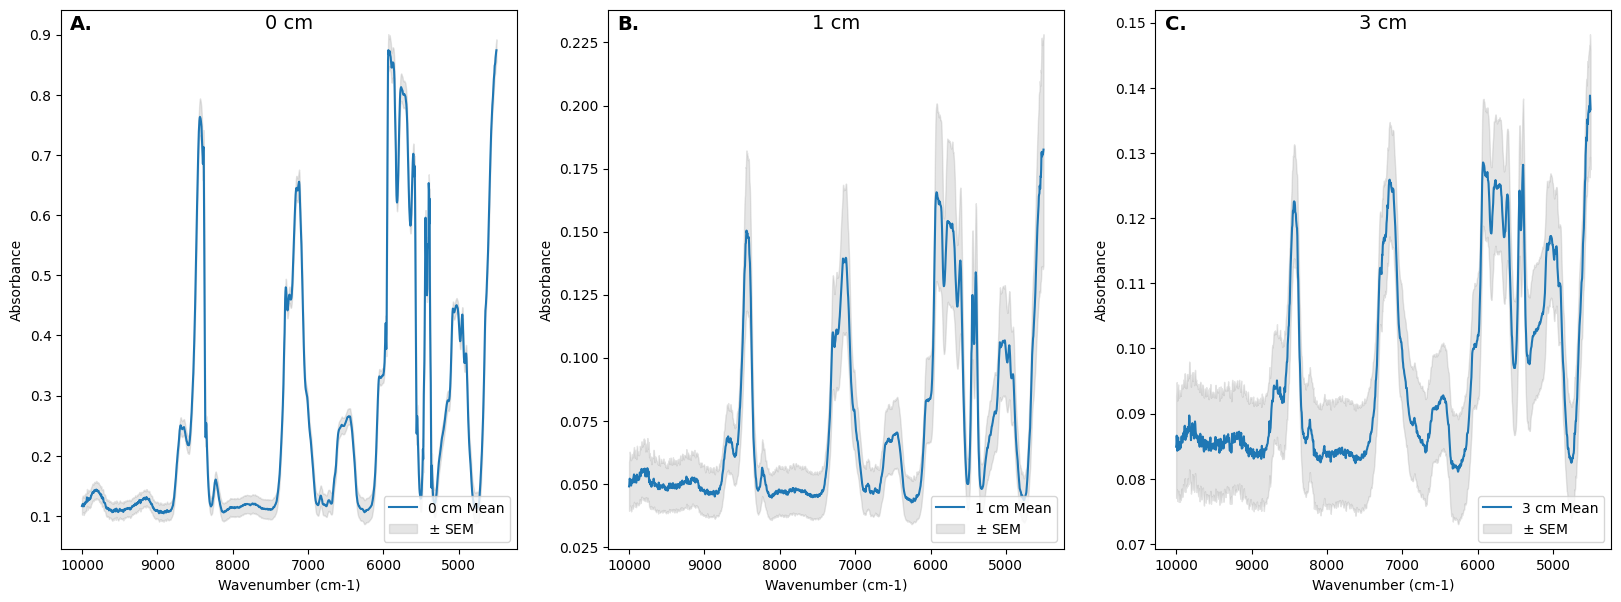

In [26]:
fig, axs = plt.subplots(1,3, figsize=(20,7))
panels = ["A.", "B.", "C.", "D."]
sem1 = data_exp1.groupby(data_exp1.index).std().div(np.sqrt(data_exp1.groupby(data_exp1.index).count()))
for i, ax in enumerate(axs.flatten()):
    mean_data = data_exp1.loc[labels[i]].mean()
    median_data = data_exp1.loc[labels[i]].median()
    ax.plot(data_exp1.columns, mean_data, label=labels[i]+" Mean")
    ax.fill_between(data_exp1.columns, mean_data+sem1.loc[labels[i]], mean_data-sem1.loc[labels[i]], color='gray', alpha=0.2, label=r'$\pm$ SEM')
    # ax.plot(data_exp1.columns, mean_data+sem1.loc[labels[i]], label=r'$\pm$ SEM', color='gray', alpha=0.2)
    # ax.plot(data_exp1.columns, mean_data-sem1.loc[labels[i]], color='gray', alpha=0.2)
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(labels[i], y=0.95, fontsize=14)
    ax.annotate(panels[i], xy=(0.02, 0.99), xycoords='axes fraction', fontsize=14, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.legend(loc='lower right')
plt.show()

### ML Clustering

In [9]:
from sklearn.decomposition import PCA


def plot_PCA(X_features, y_label, ax):
    #convert the features into the 2 top features
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(X_features)
    #principalDf = pd.DataFrame(data = principalComponents, columns =['principal component 1', 'principal component 2'])
    #principalDf.head(5)
    #data[['group']].head()
    #finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
    df = pd.DataFrame()
    df["y"] = y_label
    df["comp-1"] = principalComponents[:,0]
    df["comp-2"] = principalComponents[:,1]

    scatter_plot = sns.scatterplot(x="comp-1", 
                                y="comp-2", hue=df.y.tolist(),
                                palette=sns.color_palette("hls", len(set(y_label))),
                                data=df, 
                                ax=ax
                                )

    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # plt.show()

    #plt.savefig('PCA – No Processing.png')

In [10]:
#t-SNE
from sklearn.manifold import TSNE

def plot_TSNE(X_features, y_label, ax, n_components=2, verbose=1, random_state=123):
    tsne = TSNE(n_components=n_components, verbose=verbose, random_state=random_state)
    z = tsne.fit_transform(X_features)
    df = pd.DataFrame()
    df["y"] = y_label
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    scatter_plot = sns.scatterplot(x="comp-1", 
                                y="comp-2", 
                                hue=df.y.tolist(),
                                palette=sns.color_palette("hls", len(set(y_label))),
                                data=df, 
                                ax=ax
                                )

    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # plt.show()

In [11]:
#phate
import phate

def plot_PHATE(X_features, y_label, ax, knn=5, decay=15, t=12):
    phate_op = phate.PHATE()
    phate_op.set_params(knn=knn, decay=decay, t=t)
    #knn : Number of nearest neighbors (default: 5).
    #Increase this (e.g. to 20) if your PHATE embedding appears verydisconnected.
    #You should also consider increasing knn if your dataset is extremely large(e.g. >100k cells)
    #decay : Alpha decay (default: 15). Decreasing decay increases connectivity on the graph, increasing decay decreases connectivity.
    #This rarely needs to be tuned. Set it to None for a k-nearest neighbors kernel.

    data_phate = phate_op.fit_transform(X_features)
    result_phate = pd.DataFrame()
    result_phate["y"] = y_label
    result_phate["PHATE-1"] = data_phate[:,0]
    result_phate["PHATE-2"] = data_phate[:,1]

    sns.scatterplot(x="PHATE-1", 
                    y="PHATE-2", 
                    hue=result_phate.y.tolist(),
                    palette=sns.color_palette("hls", len(set(y_label))),
                    data=result_phate,
                    ax=ax
                    )

    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # plt.show()
# plt.savefig('PHATE – No Processing.png')

In [12]:
#UMAP
import umap

def plot_UMAP(X_features, y_label, ax):
    plt.rcParams['figure.figsize'] = (6,5)
    #mapper = umap.UMAP().fit(X_features)
    #umap.plot.points(mapper, labels=y_label)
    embedding = umap.UMAP(n_neighbors=10,
    min_dist=0.5,n_components=2,
    metric='correlation').fit_transform(X_features)
    result = pd.DataFrame()
    result["y"] = y_label
    result["UMAP-1"] = embedding[:,0]
    result["UMAP-2"] = embedding[:,1]

    sns.scatterplot(x="UMAP-1", 
                    y="UMAP-2", 
                    hue=result.y.tolist(),
                    palette=sns.color_palette("hls", len(set(y_label))),
                    data=result, 
                    ax=ax
                    )

    
    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # plt.show()

In [51]:
#read the data
n = len(data_exp1.columns)
X_features = data_exp1.iloc[:, 1:n]
y_label = data_exp1.index

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 62 samples in 0.000s...
[t-SNE] Computed neighbors for 62 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 62 / 62
[t-SNE] Mean sigma: 2.524953
[t-SNE] KL divergence after 250 iterations with early exaggeration: 43.976597
[t-SNE] KL divergence after 850 iterations: 0.019757
Calculating PHATE...
  Running PHATE on 62 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 2.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.02 seconds.
Calculated PHATE in 0.02 seconds.


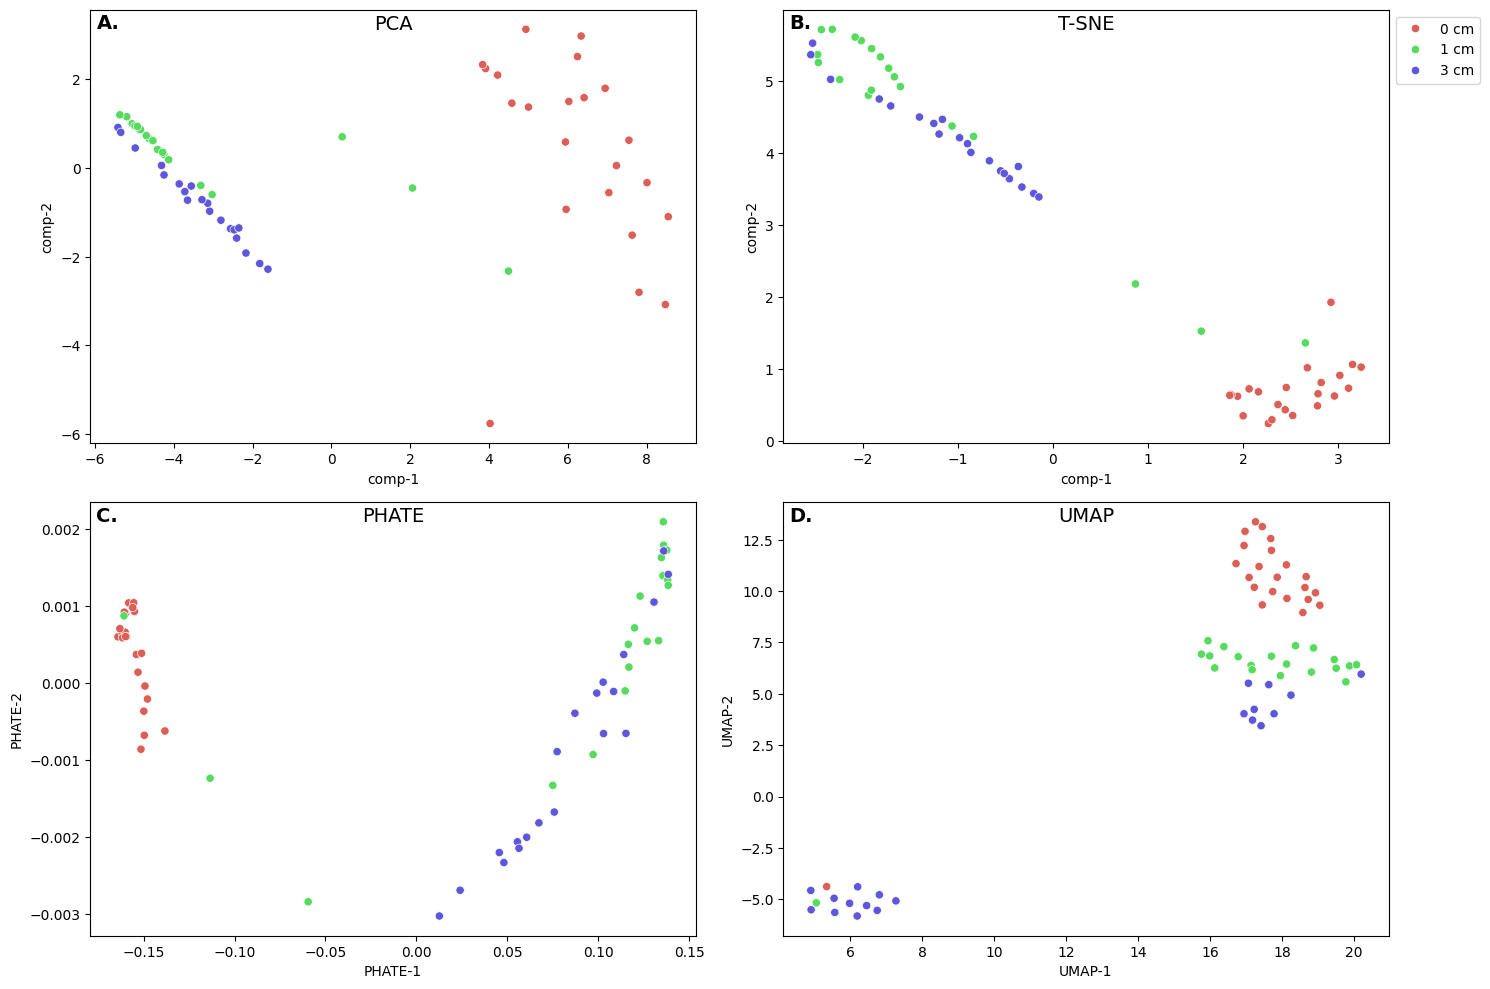

In [52]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

# fig.suptitle("Experiment 1")
plt.tight_layout()
plt.show()

## Experiment 2

### Load Data

In [33]:
fps = ["./data/exp1/0/*.csv", "./data/exp2/PEG/*.csv", "./data/exp2/PMMA/*.csv", "./data/exp2/unknown/*.csv"] # Path to folders for each material
labels = ["PDMS", "PEG", "PMMA", "Unknown"] # Labels for each material

In [34]:
# data_exp2 = no_processing(fps, labels)
# cols_to_drop = [col for col in data_exp2.columns if col <= 4500] # Columns with wavenumber <= 4500 are dropped
# data_exp2 = data_exp2.drop(columns=cols_to_drop)
# data_exp2

In [35]:
data_exp2 = processing_pipeline(fps, labels)
cols_to_drop = [col for col in data_exp2.columns if col <= 4500]
data_exp2 = data_exp2.drop(columns=cols_to_drop)
data_exp2

Wavenumber,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.040,4531.896,4535.754,...,9966.316,9970.173,9974.030,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.030
PDMS,0.910284,0.907170,0.896609,0.898106,0.881138,0.891954,0.911804,0.881265,0.867455,0.856410,...,0.043194,0.040688,0.046407,0.050346,0.048324,0.048773,0.042298,0.039377,0.038648,0.035524
PDMS,0.919819,0.917270,0.916822,0.912766,0.901004,0.889010,0.883041,0.866257,0.859793,0.856709,...,0.249877,0.252822,0.254402,0.255227,0.249945,0.247794,0.250518,0.253073,0.249822,0.250051
PDMS,0.577242,0.587938,0.590356,0.586986,0.583811,0.590099,0.600382,0.594289,0.584287,0.583233,...,0.044647,0.040857,0.029216,0.019057,0.027278,0.029756,0.035879,0.042034,0.042723,0.040403
PDMS,0.817137,0.821874,0.828413,0.830845,0.807165,0.795645,0.781011,0.774507,0.780813,0.776570,...,0.160807,0.167931,0.166653,0.167529,0.175702,0.167865,0.172136,0.178191,0.169901,0.166752
PDMS,0.938366,0.933872,0.935813,0.942017,0.930836,0.923569,0.911960,0.894824,0.894966,0.902934,...,0.170559,0.171120,0.169162,0.171076,0.172641,0.168153,0.168365,0.166690,0.165960,0.167743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unknown,0.555258,0.556772,0.560092,0.556223,0.554091,0.554223,0.552431,0.560476,0.564071,0.570377,...,0.062581,0.061989,0.061168,0.060477,0.058960,0.063098,0.066309,0.062699,0.063096,0.061129
Unknown,0.586003,0.593413,0.589558,0.598289,0.603600,0.606577,0.610223,0.606317,0.603439,0.606896,...,0.123145,0.124818,0.124524,0.126314,0.127380,0.129594,0.127124,0.126583,0.124586,0.125121
Unknown,0.579945,0.592876,0.584950,0.580428,0.582088,0.575230,0.575615,0.583541,0.583483,0.592932,...,0.080313,0.077472,0.077117,0.078712,0.079774,0.082540,0.079884,0.077831,0.076295,0.074526
Unknown,0.570594,0.573988,0.576377,0.572245,0.578236,0.583994,0.586108,0.586958,0.589191,0.591778,...,0.045519,0.042929,0.042077,0.044491,0.044328,0.043269,0.042787,0.042323,0.040255,0.040373


### Plot Spectrum

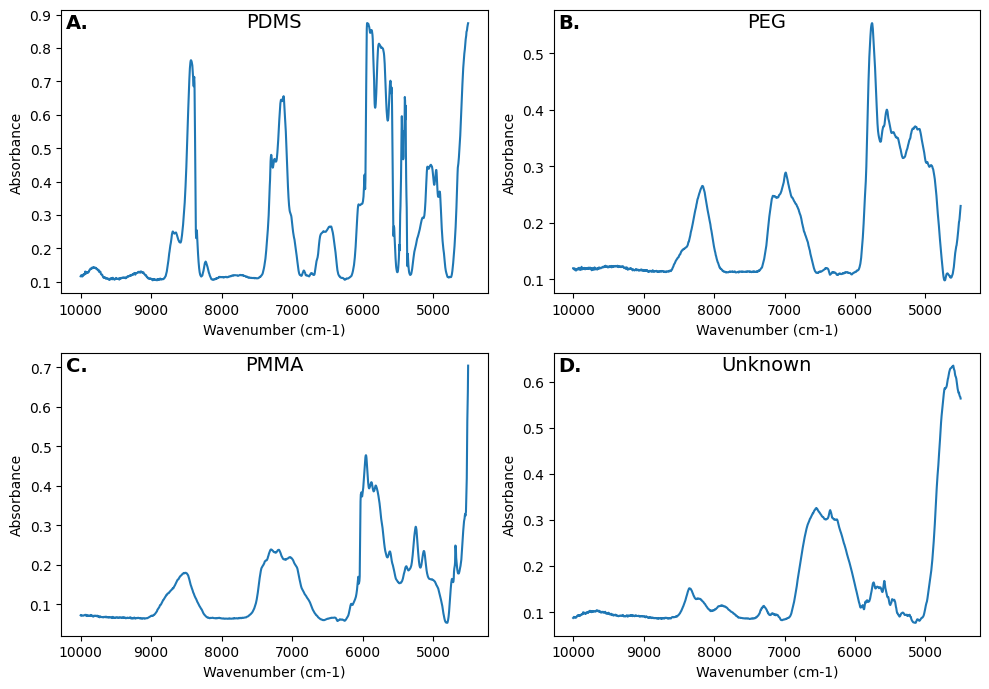

In [36]:
fig, axs = plt.subplots(2,2, figsize=(10,7))
sem2 = data_exp2.groupby(data_exp2.index).std().div(np.sqrt(data_exp2.groupby(data_exp2.index).count()))
for ax, label, panel in zip(axs.flatten(), labels, panels):
    mean_data = data_exp2.loc[label].mean()
    ax.plot(data_exp2.columns, mean_data, label=label+" Mean")
    # ax.fill_between(data_exp2.columns, mean_data+sem2.loc[labels[i]], mean_data-sem2.loc[labels[i]], color='gray', alpha=0.2, label=r'$\pm$ SEM')
    # ax.plot(data_exp2.columns, mean_data+sem2.loc[labels[i]], label=r'$\pm$ SEM', color='gray', alpha=0.2)
    # ax.plot(data_exp2.columns, mean_data-sem2.loc[labels[i]], color='gray', alpha=0.2)
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(label, y=0.91, fontsize=14)
    ax.text(0.01, 0.99, panel,
           transform=ax.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    ax.invert_xaxis()
    # ax.legend(loc='lower right')
    
plt.tight_layout()
plt.show()

In [41]:
sem2

Wavenumber,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.040,4531.896,4535.754,...,9966.316,9970.173,9974.030,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.030
PDMS,0.018188,0.017880,0.017733,0.017461,0.017262,0.016634,0.015982,0.015848,0.017059,0.016887,...,0.014091,0.013980,0.014089,0.014280,0.014079,0.013779,0.013898,0.014105,0.014026,0.013865
PEG,0.012791,0.013004,0.012979,0.012909,0.013075,0.013096,0.012768,0.012855,0.012723,0.013017,...,0.011833,0.011772,0.011987,0.011727,0.011374,0.011501,0.011486,0.011350,0.011347,0.011406
PMMA,0.023847,0.016070,0.020842,0.024032,0.021130,0.019950,0.016329,0.013121,0.013024,0.012824,...,0.006494,0.006252,0.006329,0.006425,0.006237,0.006137,0.006134,0.006104,0.006079,0.006259
Unknown,0.006273,0.006537,0.006278,0.006330,0.006309,0.006328,0.006207,0.006440,0.005873,0.006067,...,0.009267,0.009289,0.009314,0.009441,0.009606,0.009529,0.009331,0.009391,0.009336,0.009261


In [43]:
for row in sem2.index: 
    print(f'{row} Average SEM = {sem2.loc[row].mean():4f}')

PDMS Average SEM = 0.015916
PEG Average SEM = 0.012292
PMMA Average SEM = 0.007634
Unknown Average SEM = 0.008790


### ML Clustering

In [45]:
#read the data
data_no_unk = data_exp2.drop("Unknown")
n = len(data_no_unk.columns)
X_features = data_no_unk.iloc[:, 1:n]
y_label = data_no_unk.index

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 62 samples in 0.001s...
[t-SNE] Computed neighbors for 62 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 62 / 62
[t-SNE] Mean sigma: 3.497245
[t-SNE] KL divergence after 250 iterations with early exaggeration: 46.481678
[t-SNE] KL divergence after 800 iterations: 0.019540
Calculating PHATE...
  Running PHATE on 62 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -11.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.02 seconds.
Calculated PHATE in 0.03 seconds.


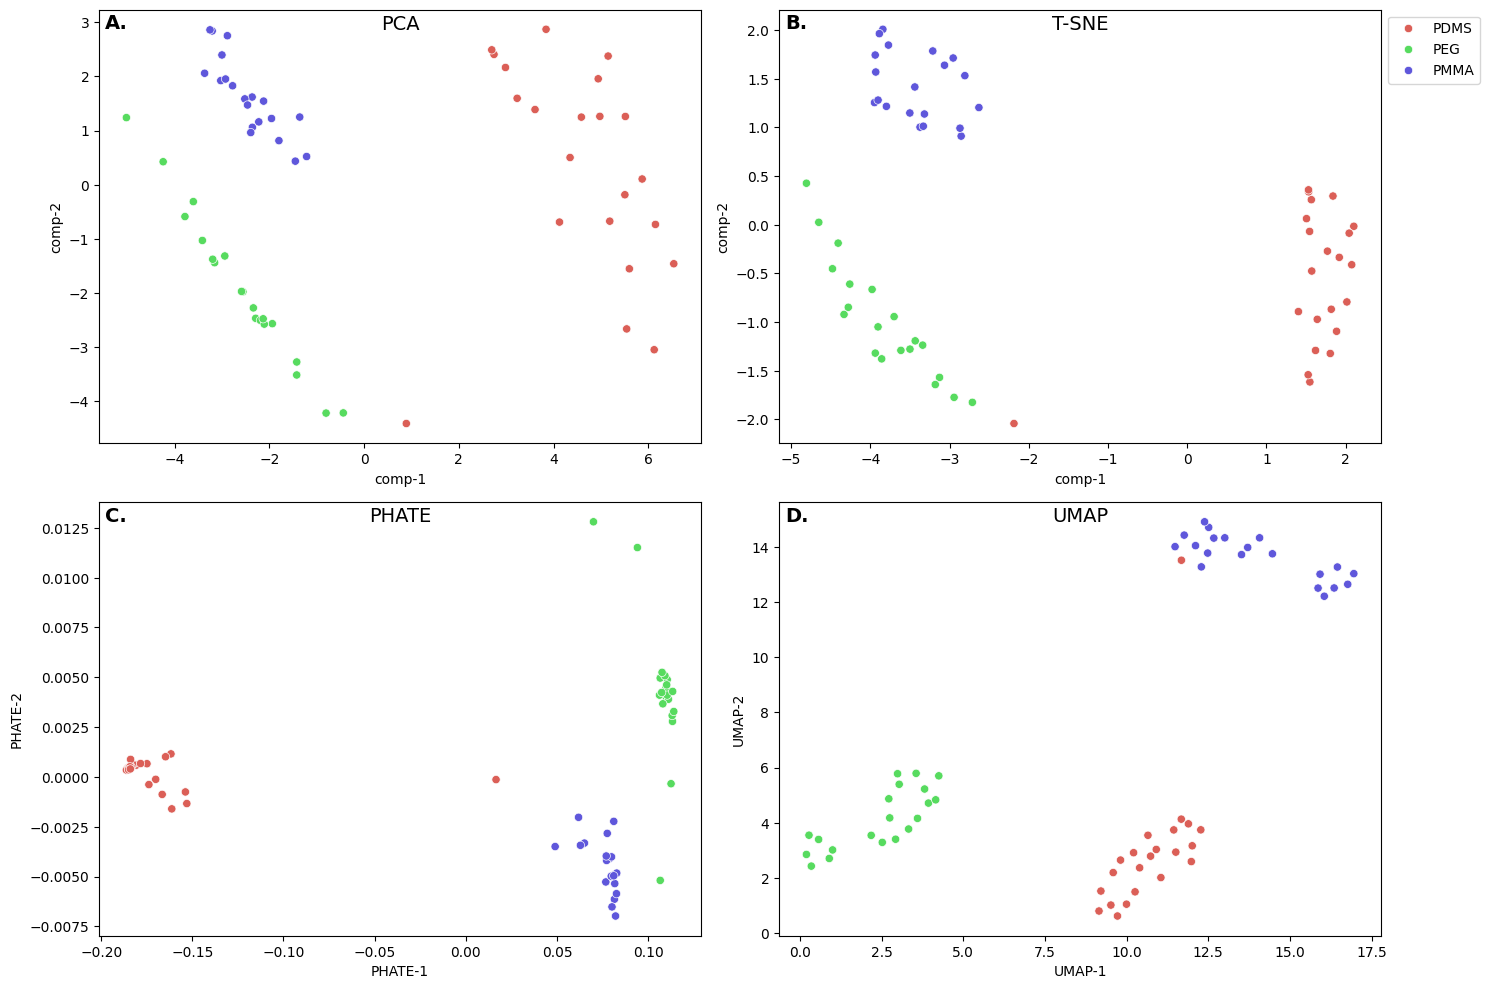

In [46]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=20)
plot_UMAP(X_features, y_label, ax[3])

ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

# fig.suptitle("Experiment 1")
plt.tight_layout()
plt.show()

In [47]:
n = len(data_exp2.columns)
X_features = data_exp2.iloc[:, 1:n]
y_label = data_exp2.index

[t-SNE] Computing 82 nearest neighbors...
[t-SNE] Indexed 83 samples in 0.000s...
[t-SNE] Computed neighbors for 83 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 83 / 83
[t-SNE] Mean sigma: 3.367581
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.495117
[t-SNE] KL divergence after 700 iterations: 0.028396
Calculating PHATE...
  Running PHATE on 83 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 10.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.03 seconds.
Calculated PHATE in 0.03 seconds.


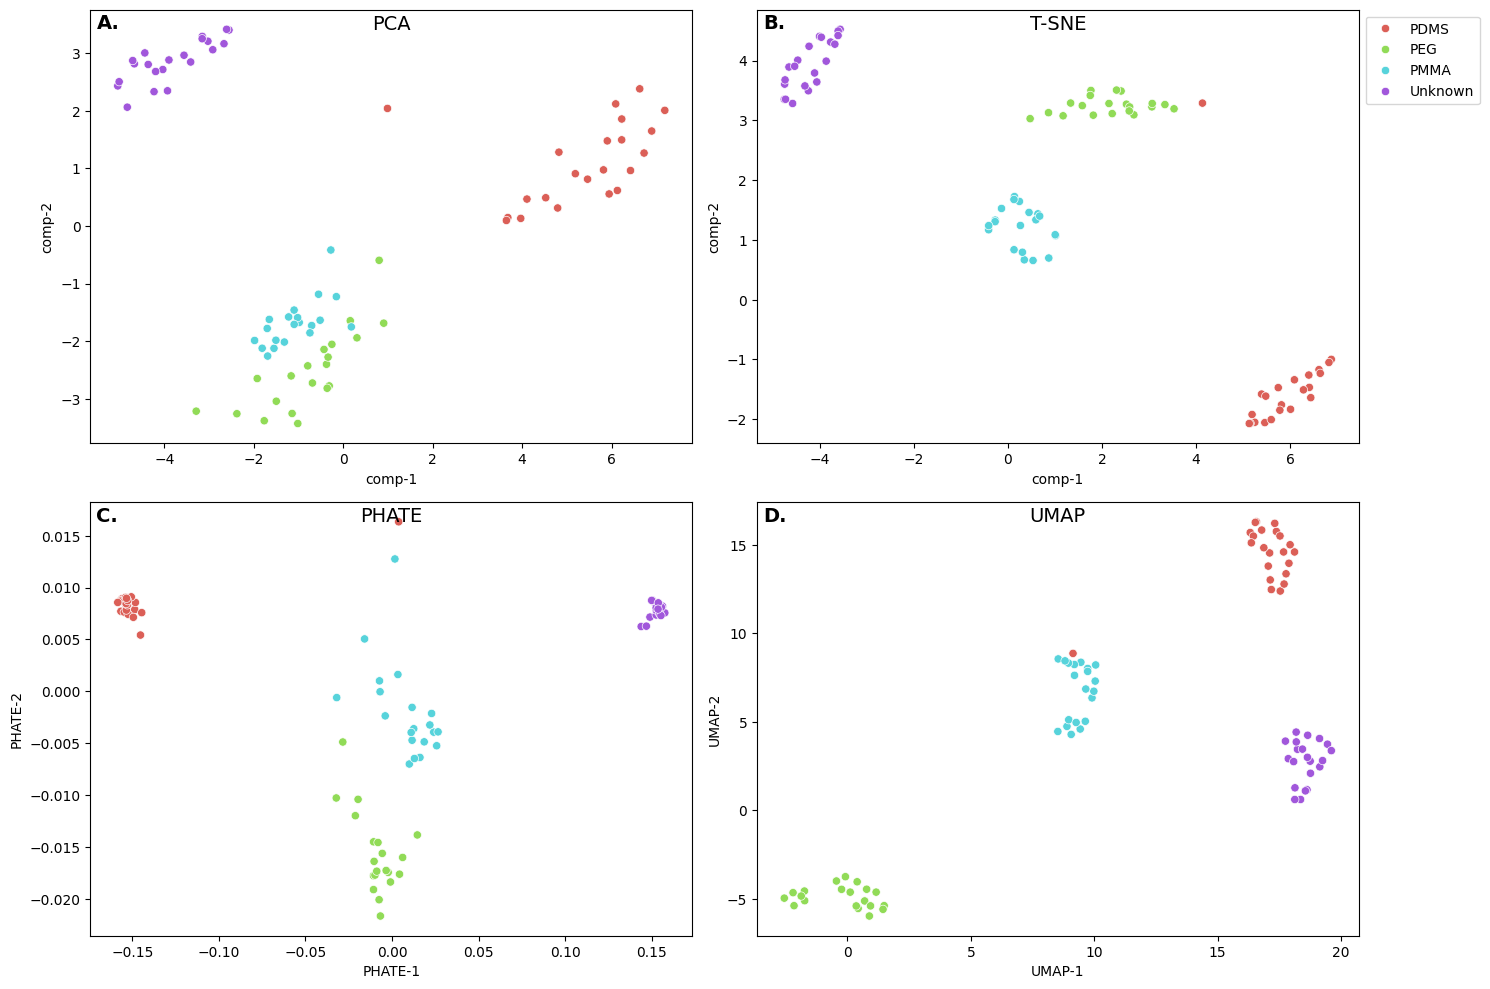

In [49]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, 
           panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

# fig.suptitle("Experiment 1")
plt.tight_layout()
plt.show()